In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('dataset/gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,emaar mgf the palm drive,sector 66,3.98,18090.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,4,3+,...,2200.0,NaN,NaN,0,1,0,0,0,1,123
1,flat,emaar digihomes,sector 62,2.15,14257.0,1508.0,Carpet area: 1508 (140.1 sq.m.),2,2,3,...,NaN,NaN,1508.0,0,0,0,0,0,0,101
2,flat,m3m heights,sector 65,2.44,13300.0,1835.0,Super Built up area 1828(169.83 sq.m.),3,3,2,...,1828.0,NaN,NaN,0,0,0,0,0,0,31
3,flat,the close south,sector 50,3.10,12444.0,2491.0,Super Built up area 2491(231.42 sq.m.)Built Up...,3,4,3+,...,2491.0,2450.0,2250.0,0,1,0,0,0,1,165
4,flat,unitech the residences,sector 33,1.55,9872.0,1570.0,Super Built up area 1570(145.86 sq.m.),3,4,1,...,1570.0,NaN,NaN,0,1,0,0,0,0,37


In [4]:
df.shape

(3803, 23)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   str    
 1   society              3802 non-null   str    
 2   sector               3803 non-null   str    
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   str    
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   str    
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   str    
 12  agePossession        3803 non-null   str    
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   float64
 16 

In [7]:
df.duplicated().sum()

np.int64(126)

In [8]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(3677, 23)

In [11]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,emaar mgf the palm drive,sector 66,3.98,18090.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,4,3+,...,2200.0,NaN,NaN,0,1,0,0,0,1,123
1,flat,emaar digihomes,sector 62,2.15,14257.0,1508.0,Carpet area: 1508 (140.1 sq.m.),2,2,3,...,NaN,NaN,1508.0,0,0,0,0,0,0,101
2,flat,m3m heights,sector 65,2.44,13300.0,1835.0,Super Built up area 1828(169.83 sq.m.),3,3,2,...,1828.0,NaN,NaN,0,0,0,0,0,0,31
3,flat,the close south,sector 50,3.10,12444.0,2491.0,Super Built up area 2491(231.42 sq.m.)Built Up...,3,4,3+,...,2491.0,2450.0,2250.0,0,1,0,0,0,1,165
4,flat,unitech the residences,sector 33,1.55,9872.0,1570.0,Super Built up area 1570(145.86 sq.m.),3,4,1,...,1570.0,NaN,NaN,0,1,0,0,0,0,37


<Axes: xlabel='property_type'>

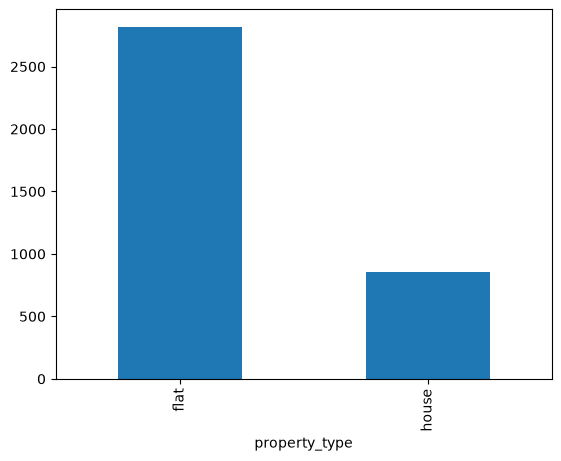

In [12]:
df['property_type'].value_counts().plot(kind='bar')

Observations
Flats are in majority(75 percent) and there are less number of houses(~25 percent)
No missing values

In [13]:
df['society'].value_counts().shape

(676,)

In [14]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
                                       ... 
uphaar homes                              1
allure homes                              1
professional society                      1
naman residency                           1
imperia elvedor                           1
Name: count, Length: 676, dtype: int64

In [15]:
df[df['society']!='independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023511
ss the leaf                             0.046395
shapoorji pallonji joyville gurugram    0.059561
dlf new town heights                    0.072727
signature global park                   0.083699
                                          ...   
dlf the primus                          0.490282
umang winter hills                      0.494357
the close north                         0.498433
mvn athens                              0.502194
unitech uniworld resorts                0.505956
Name: proportion, Length: 75, dtype: float64

In [16]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(273),
 'Very Low (1)': np.int64(308)}

<Axes: xlabel='society'>

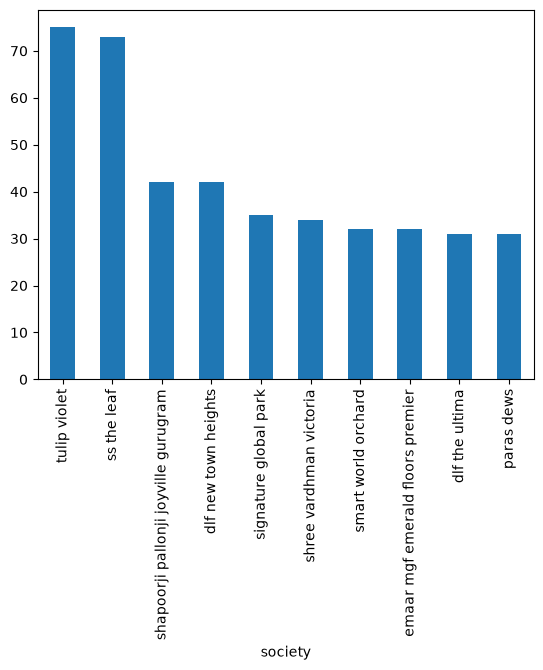

In [17]:
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [18]:
df['society'].isnull().sum()

np.int64(1)

In [19]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2246,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


Observations
Around 13% properties comes under independent tag.
There are 676 societies.
The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
Very High (>100): Only 1 society has more than 100 listings.
High (50-100): 2 societies have between 50 to 100 listings.
Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
Low (2-9): 273 societies have between 2 to 9 listings.
Very Low (1): A significant number, 308 societies, have only 1 listing.
1 missing value

In [20]:
df['sector'].value_counts()

sector
sohna road    154
sector 85     108
sector 102    107
sector 92     100
sector 69      93
             ... 
sector 73       3
sector 88b      3
sector 17b      3
sector 27       3
sector 37       1
Name: count, Length: 113, dtype: int64

In [21]:
df['sector'].value_counts().shape

(113,)

<Axes: xlabel='sector'>

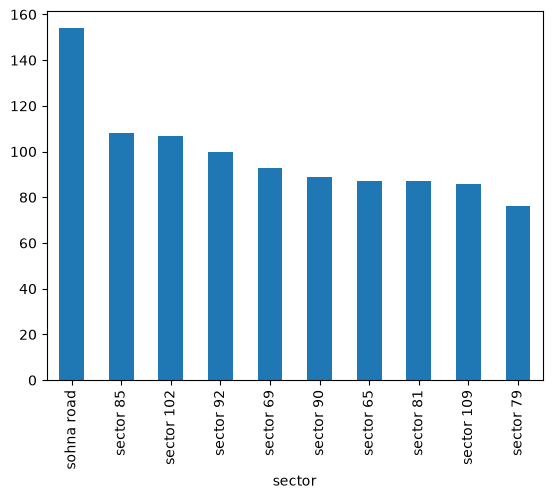

In [22]:
df['sector'].value_counts().head(10).plot(kind='bar')

In [23]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(63),
 'Low (2-9)': np.int64(21),
 'Very Low (1)': np.int64(1)}

Observations
There are a total of 113 unique sectors in the dataset.
Frequency distribution of sectors:
Very High (>100): 3 sectors have more than 100 listings.
High (50-100): 25 sectors have between 50 to 100 listings.
Average (10-49): A majority, 63 sectors, fall in this range with 10 to 49 listings each.
Low (2-9): 21 sectors have between 2 to 9 listings.
Very Low (1): Interestingly, there is only 1 sector with only 1 listing.

In [24]:
df['price'].value_counts()

price
1.25     80
1.20     64
1.50     64
0.90     63
1.10     62
         ..
9.40      1
4.78      1
2.34      1
4.12      1
14.75     1
Name: count, Length: 473, dtype: int64

In [25]:
df['price'].isnull().sum()

np.int64(17)

In [26]:
df['price'].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

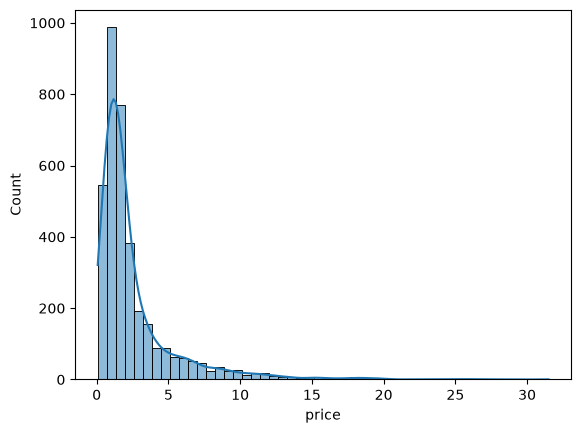

In [27]:
sns.histplot(df['price'],kde=True,bins=50)

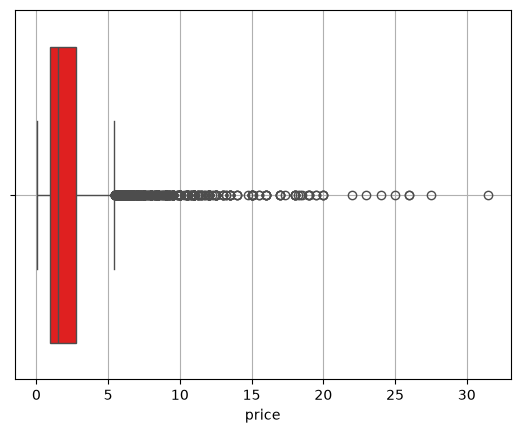

In [28]:
sns.boxplot(x=df['price'],color='red')
plt.grid()

Descriptive Statistics:

Count: There are 3,660 non-missing price entries.
Mean Price: The average price is approximately 2.53 crores.
Median Price: The median (or 50th percentile) price is 1.52 crores.
Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.
Visualizations:

Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
Missing Values: There are 17 missing values in the price column.